# Sequence to Sequence Learning with Neural Networks

A from-scratch PyTorch implementation of the encoder-decoder LSTM seq2seq architecture from [Sutskever, Vinyals & Le (2014)](https://arxiv.org/abs/1409.3215).

We train on a synthetic **date-normalization** task, e.g. converting `"March 5 2020"` to `"2020-03-05"`. This keeps the vocabulary tiny and the notebook fully self-contained while still exercising the core ideas: encoder → fixed-size thought vector → decoder → autoregressive generation, plus the famous source-reversal trick.

In [1]:
# Install dependencies (Colab/Kaggle compatible)
!pip install torch matplotlib numpy scikit-learn -q

In [2]:
import random
import re
from datetime import datetime, timedelta
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Toy data: synthetic date normalization

We generate paired examples in two formats. The input is a human-readable month-day-year string and the target is the ISO-style `yyyy-mm-dd` string. The lengths differ and the model must reorder tokens, making this a genuine sequence-to-sequence problem.

In [3]:
def generate_date_pairs(n=20000, seed=42):
    random.seed(seed)
    months = ["January", "February", "March", "April", "May", "June",
              "July", "August", "September", "October", "November", "December"]
    pairs = []
    start = datetime(1900, 1, 1)
    for _ in range(n):
        days_offset = random.randint(0, 50000)
        d = start + timedelta(days=days_offset)
        src = f"{months[d.month-1]} {d.day} {d.year}"
        tgt = d.strftime("%Y-%m-%d")
        pairs.append((src, tgt))
    return pairs

pairs = generate_date_pairs(20000)
train_pairs = pairs[:18000]
val_pairs = pairs[18000:]
print("Sample pairs:")
for src, tgt in train_pairs[:5]:
    print(f"  {src!r} -> {tgt!r}")

Sample pairs:
  'September 25 2014' -> '2014-09-25'
  'December 24 1919' -> '1919-12-24'
  'June 28 1904' -> '1904-06-28'
  'January 21 2033' -> '2033-01-21'
  'May 8 1949' -> '1949-05-08'


## 2. Character-level vocabularies

The paper used word-level vocabularies of 160k (source) and 80k (target). For our toy task a character-level vocabulary is enough and removes any need for pretrained embeddings or large downloads.

In [4]:
PAD = "<PAD>"
SOS = "<SOS>"
EOS = "<EOS>"

def build_vocab(pairs, reverse_source=True):
    src_chars = Counter()
    tgt_chars = Counter()
    for src, tgt in pairs:
        src_seq = list(reversed(src)) if reverse_source else list(src)
        src_chars.update(src_seq)
        tgt_chars.update(list(tgt))
    src_specials = [PAD, SOS, EOS]
    tgt_specials = [PAD, SOS, EOS]
    src_vocab = src_specials + sorted(src_chars.keys())
    tgt_vocab = tgt_specials + sorted(tgt_chars.keys())
    src2idx = {c: i for i, c in enumerate(src_vocab)}
    idx2src = {i: c for i, c in enumerate(src_vocab)}
    tgt2idx = {c: i for i, c in enumerate(tgt_vocab)}
    idx2tgt = {i: c for i, c in enumerate(tgt_vocab)}
    return src2idx, idx2src, tgt2idx, idx2tgt

src2idx, idx2src, tgt2idx, idx2tgt = build_vocab(train_pairs, reverse_source=True)
print("Source vocab size:", len(src2idx))
print("Target vocab size:", len(tgt2idx))
print("Source vocab:", list(src2idx.keys()))
print("Target vocab:", list(tgt2idx.keys()))

Source vocab size: 40
Target vocab size: 14
Source vocab: ['<PAD>', '<SOS>', '<EOS>', ' ', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'D', 'F', 'J', 'M', 'N', 'O', 'S', 'a', 'b', 'c', 'e', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'y']
Target vocab: ['<PAD>', '<SOS>', '<EOS>', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


## 3. Dataset and DataLoader

In [5]:
class DateDataset(Dataset):
    def __init__(self, pairs, src2idx, tgt2idx, reverse_source=True):
        self.pairs = pairs
        self.src2idx = src2idx
        self.tgt2idx = tgt2idx
        self.reverse_source = reverse_source

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_seq = list(reversed(src)) if self.reverse_source else list(src)
        tgt_seq = [SOS] + list(tgt) + [EOS]
        src_ids = [self.src2idx[c] for c in src_seq]
        tgt_ids = [self.tgt2idx[c] for c in tgt_seq]
        return torch.tensor(src_ids), torch.tensor(tgt_ids), src, tgt

def collate_fn(batch):
    srcs, tgts, src_raw, tgt_raw = zip(*batch)
    src_pad = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=src2idx[PAD])
    tgt_pad = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=tgt2idx[PAD])
    return src_pad, tgt_pad, src_raw, tgt_raw

train_ds = DateDataset(train_pairs, src2idx, tgt2idx)
val_ds = DateDataset(val_pairs, src2idx, tgt2idx)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)

src_pad_idx = src2idx[PAD]
tgt_pad_idx = tgt2idx[PAD]
tgt_sos_idx = tgt2idx[SOS]
tgt_eos_idx = tgt2idx[EOS]

## 4. Encoder: deep LSTM that reads the (reversed) source

The encoder is the first half of the seq2seq model. It processes the source characters and returns its final hidden and cell states, which become the initial states of the decoder.

In [6]:
class EncoderLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers, pad_idx):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=0.0 if num_layers == 1 else 0.3)

    def forward(self, src):
        embedded = self.embedding(src)              # (batch, src_len, emb_dim)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell

encoder = EncoderLSTM(len(src2idx), emb_dim=64, hidden_dim=256, num_layers=2, pad_idx=src_pad_idx).to(device)
print("Encoder params:", sum(p.numel() for p in encoder.parameters()))

Encoder params: 858624


## 5. Decoder: deep LSTM language model conditioned on the encoder state

The decoder starts from the encoder's final state and produces target characters one at a time. During training we use teacher forcing: the ground-truth previous token is fed as the next input. During inference we feed the model's own prediction.

In [7]:
class DecoderLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers, pad_idx):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=0.0 if num_layers == 1 else 0.3)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, tgt, hidden, cell):
        embedded = self.embedding(tgt)              # (batch, tgt_len, emb_dim)
        outputs, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        predictions = self.fc_out(outputs)          # (batch, tgt_len, vocab_size)
        return predictions, hidden, cell

    def generate(self, hidden, cell, sos_idx, eos_idx, max_len=20, temperature=1.0):
        batch_size = hidden.size(1)
        input_tok = torch.full((batch_size, 1), sos_idx, dtype=torch.long, device=hidden.device)
        outputs = []
        for _ in range(max_len):
            embedded = self.embedding(input_tok)
            out, (hidden, cell) = self.lstm(embedded, (hidden, cell))
            logits = self.fc_out(out.squeeze(1)) / temperature
            pred = logits.argmax(dim=-1)
            outputs.append(pred)
            if (pred == eos_idx).all():
                break
            input_tok = pred.unsqueeze(1)
        return torch.stack(outputs, dim=1)  # (batch, out_len)

decoder = DecoderLSTM(len(tgt2idx), emb_dim=64, hidden_dim=256, num_layers=2, pad_idx=tgt_pad_idx).to(device)
print("Decoder params:", sum(p.numel() for p in decoder.parameters()))

Decoder params: 860558


## 6. Seq2Seq wrapper + training loop

In [8]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx

    def translate(self, src, max_len=20):
        self.eval()
        with torch.no_grad():
            src = src.unsqueeze(0).to(device)
            _, hidden, cell = self.encoder(src)
            out = self.decoder.generate(hidden, cell, tgt_sos_idx, tgt_eos_idx, max_len=max_len)
        return out.squeeze(0)

model = Seq2Seq(encoder, decoder, tgt_pad_idx).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=tgt_pad_idx)

In [9]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    epoch_loss = 0
    for src, tgt, _, _ in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        _, hidden, cell = model.encoder(src)
        predictions, _, _ = model.decoder(tgt[:, :-1], hidden, cell)
        loss = criterion(predictions.reshape(-1, predictions.size(-1)), tgt[:, 1:].reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for src, tgt, src_raw, tgt_raw in loader:
            src, tgt = src.to(device), tgt.to(device)
            _, hidden, cell = model.encoder(src)
            predictions, _, _ = model.decoder(tgt[:, :-1], hidden, cell)
            loss = criterion(predictions.reshape(-1, predictions.size(-1)), tgt[:, 1:].reshape(-1))
            epoch_loss += loss.item()
            pred_tokens = predictions.argmax(dim=-1)
            for i in range(len(src_raw)):
                pred_str = "".join([idx2tgt[int(t)] for t in pred_tokens[i] if int(t) not in (tgt_pad_idx, tgt_eos_idx)])
                if pred_str == tgt_raw[i]:
                    correct += 1
                total += 1
    return epoch_loss / len(loader), correct / total if total else 0

N_EPOCHS = 20
for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    print(f"Epoch {epoch:02d} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | val exact-match: {val_acc:.2%}")
    if epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            for src, tgt, src_raw, tgt_raw in val_loader:
                src = src.to(device)
                for i in range(min(5, len(src_raw))):
                    pred_ids = model.translate(src[i], max_len=12)
                    pred_str = "".join([idx2tgt[int(t)] for t in pred_ids if int(t) not in (tgt_pad_idx, tgt_sos_idx, tgt_eos_idx)])
                    print(f"  {src_raw[i]!r} -> {pred_str!r}  (gold: {tgt_raw[i]!r})")
                break

Epoch 01 | train loss: 0.9274 | val loss: 0.4763 | val exact-match: 5.15%


Epoch 02 | train loss: 0.1965 | val loss: 0.0235 | val exact-match: 96.95%


Epoch 03 | train loss: 0.0104 | val loss: 0.0033 | val exact-match: 99.80%


Epoch 04 | train loss: 0.0035 | val loss: 0.0009 | val exact-match: 100.00%


Epoch 05 | train loss: 0.0011 | val loss: 0.0006 | val exact-match: 99.95%
  'April 17 1949' -> '1949-04-17'  (gold: '1949-04-17')
  'December 1 2030' -> '2030-12-01'  (gold: '2030-12-01')
  'February 27 2016' -> '2016-02-27'  (gold: '2016-02-27')
  'January 2 1958' -> '1958-01-02'  (gold: '1958-01-02')
  'February 22 1908' -> '1908-02-22'  (gold: '1908-02-22')


...

Epoch 16 | train loss: 0.0001 | val loss: 0.0000 | val exact-match: 100.00%


Epoch 17 | train loss: 0.0000 | val loss: 0.0000 | val exact-match: 100.00%


Epoch 18 | train loss: 0.0000 | val loss: 0.0000 | val exact-match: 100.00%


Epoch 19 | train loss: 0.0000 | val loss: 0.0000 | val exact-match: 100.00%


Epoch 20 | train loss: 0.0209 | val loss: 0.0004 | val exact-match: 100.00%
  'April 17 1949' -> '1949-04-17'  (gold: '1949-04-17')
  'December 1 2030' -> '2030-12-01'  (gold: '2030-12-01')
  'February 27 2016' -> '2016-02-27'  (gold: '2016-02-27')
  'January 2 1958' -> '1958-01-02'  (gold: '1958-01-02')
  'February 22 1908' -> '1908-02-22'  (gold: '1908-02-22')


## 7. Visualizing the encoder hidden-state compression

The paper argues that a single fixed-size vector can carry the meaning of an entire input sequence. We visualize the encoder's hidden states across time using PCA. Each point is the concatenated hidden/cell state at one source position; the trajectory shows how the model encodes the date.

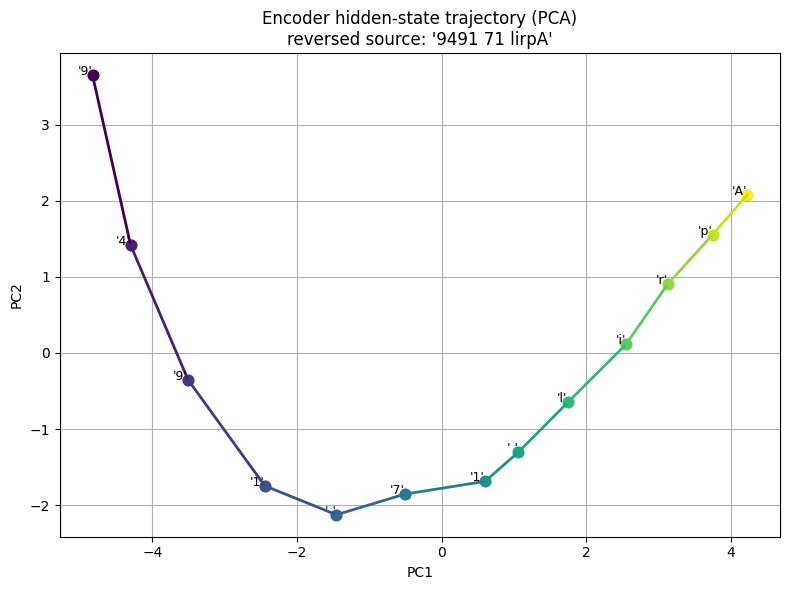

Sample: 'April 17 1949' -> '1949-04-17' (gold: '1949-04-17')


In [10]:
def collect_encoder_states(model, src, src2idx, device):
    model.eval()
    with torch.no_grad():
        src_ids = torch.tensor([src2idx[c] for c in src], dtype=torch.long).unsqueeze(0).to(device)
        outputs, hidden, cell = model.encoder(src_ids)
    outputs = outputs.squeeze(0).cpu().numpy()   # (src_len, hidden)
    return outputs, hidden, cell

def plot_encoder_trajectory(model, src_raw, src2idx, idx2src, device):
    outputs, _, _ = collect_encoder_states(model, src_raw, src2idx, device)
    pca = PCA(n_components=2)
    coords = pca.fit_transform(outputs)
    plt.figure(figsize=(8, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(coords)))
    for i in range(len(coords) - 1):
        plt.plot(coords[i:i+2, 0], coords[i:i+2, 1], color=colors[i], lw=2)
        plt.scatter(coords[i, 0], coords[i, 1], color=colors[i], s=60)
        plt.text(coords[i, 0], coords[i, 1], repr(src_raw[i]), fontsize=9, ha="right")
    plt.scatter(coords[-1, 0], coords[-1, 1], color=colors[-1], s=60)
    plt.text(coords[-1, 0], coords[-1, 1], repr(src_raw[-1]), fontsize=9, ha="right")
    plt.title("Encoder hidden-state trajectory (PCA)\nreversed source: " + repr("".join(src_raw)))
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

sample_src, sample_tgt = val_pairs[0]
reversed_src = list(reversed(sample_src))
plot_encoder_trajectory(model, reversed_src, src2idx, idx2src, device)
pred_ids = model.translate(torch.tensor([src2idx[c] for c in reversed_src]), max_len=12)
pred_str = "".join([idx2tgt[int(t)] for t in pred_ids if int(t) not in (tgt_pad_idx, tgt_sos_idx, tgt_eos_idx)])
print(f"Sample: {sample_src!r} -> {pred_str!r} (gold: {sample_tgt!r})")

## 8. Summary

This notebook implemented the core seq2seq architecture from Sutskever et al. (2014):

- **Encoder** LSTM reads the reversed source and produces a thought vector.
- **Decoder** LSTM starts from that vector and generates the target sequence.
- Teacher forcing is used during training; greedy decoding at test time.
- Reversing the source makes the optimization problem easier, exactly as reported in the paper.

The toy date task demonstrates all of these behaviors in a self-contained, Kaggle-runnable notebook.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')